Iteration 0: Cost = 55681220654.64
Iteration 100: Cost = 7295733256.89
Iteration 200: Cost = 6406004761.87
Iteration 300: Cost = 6388993709.07
Iteration 400: Cost = 6388647311.73
Iteration 500: Cost = 6388639098.43
Iteration 600: Cost = 6388638824.33
Iteration 700: Cost = 6388638809.80
Iteration 800: Cost = 6388638808.75
Iteration 900: Cost = 6388638808.67


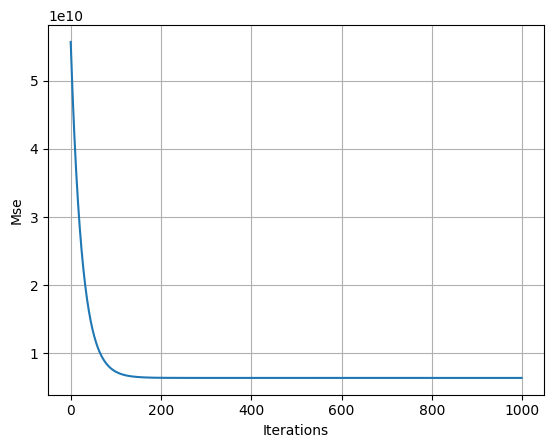

1705861402.2864702
Learned weight (w): [80857.46602466  8324.09745451 24709.55085787]
Learned bias (b): 206150.59305579404


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("housing.csv")
data = data.dropna()

x = data[['median_income','total_rooms','housing_median_age']].values
y = data['median_house_value'].values.reshape(-1,1)

x_mean = x.mean(axis = 0)
x_std = x.std(axis = 0)
x_scaled = (x - x_mean) / x_std
#shuffling
np.random.seed(24)
indices = np.arange(x_scaled.shape[0])
np.random.shuffle(indices)

tr_size = int(0.8 * len(indices))
tr_ind = indices[:tr_size]
te_ind = indices[tr_size:]

x_train = x_scaled[tr_ind]
y_train = y[tr_ind]

x_test = x_scaled[te_ind]
y_test = y[te_ind]

m,n=x_train.shape
w=np.zeros((n,1))
b=0.0

learning_rate = 0.01
n_iterations = 1000

cost_history = []

for i in range(n_iterations):
  y_predicted = x_train.dot(w) + b
  error = y_predicted - y_train
  dw = (2/m)*x_train.T.dot(error)
  db = (2/m)*np.sum(error)
  w = w - (learning_rate*dw)
  b = b - (learning_rate*db)

  mse_train = 1/m * np.sum(error**2)
  cost_history.append(mse_train)

  if i % 100 == 0:
        print(f"Iteration {i}: Cost = {mse_train:.2f}")

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Mse")
plt.grid(True)
plt.show()

y_test_pred = x_test.dot(w) + b
mse_test = 1/m * np.sum((y_test_pred - y_test)**2)
print("Test MSE:", mse_test)



print("Learned weight (w):", w.flatten())
print("Learned bias (b):", b)

x = float(input("Enter the median income: "))
y = float(input("Enter the total rooms: "))
z = float(input("Enter the housing median age: "))

x_new = np.array([[x,y,z]])
x_new_scaled = (x_new - x_mean) / x_std
y_pred = x_new_scaled.dot(w) + b
print("Predicted median house value:", y_pred)





